In [45]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.metrics import pairwise_distances
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [46]:
# CARGA DE DATOS

gdf_nodos = gpd.read_file("dataset_final.gpkg")

# Asegurar CRS métrico (EPSG:3857)
if gdf_nodos.crs is None:
    gdf_nodos = gdf_nodos.set_crs(epsg=4326)
if gdf_nodos.crs.to_epsg() != 3857:
    gdf_nodos = gdf_nodos.to_crs(epsg=3857)

# Convertir a puntos si hay polígonos o líneas
geom_types = gdf_nodos.geometry.geom_type.unique()
if not np.all(np.isin(geom_types, ["Point", "MultiPoint"])):
    gdf_nodos = gdf_nodos.copy()
    gdf_nodos["geometry"] = gdf_nodos.geometry.centroid

gdf = gdf_nodos

In [47]:
# FUNCIONES DE FITNESS

def fitness_cantidad_estaciones(estaciones_osmid, factor=1):

    return np.float64(len(estaciones_osmid) * factor) # Retorna cant de estaciones * factor de relevancia


def fitness_prioridad_simple(gdf, estaciones_osmid, peso_flujo=0.7, peso_esquinas=0.3):

    flujo_norm = gdf['flujo_total'] / (gdf['flujo_total'].max() + 1e-6) # Normalización del flujo de trafico
    esquinas_norm = gdf['esquinas_en_radio'] / (gdf['esquinas_en_radio'].max() + 1e-6) # Normalización de cantidad de esquinas
    gdf['prioridad'] = peso_flujo * flujo_norm + peso_esquinas * esquinas_norm # Cálculo de prioridad del nodo
    prioridades = gdf.loc[gdf['osmid'].isin(estaciones_osmid), 'prioridad'] # Almacenamiento
    return np.float64(prioridades.mean() if len(prioridades) > 0 else 0.0) # Retorna como fitness la media de prioridad de todas las estaciones del individuo


def fitness_cobertura_global(gdf_nodos, estaciones_idx, d_max=50000, penalizacion=1e6):
  
    # Extraer coordenadas
    coords = np.vstack((gdf_nodos.geometry.x, gdf_nodos.geometry.y)).T
    estaciones = coords[np.array(estaciones_idx)]

    # Calcular distancias nodo a estación
    dist_matrix = pairwise_distances(coords, estaciones, metric='euclidean')
    dist_min = dist_matrix.min(axis=1)

    # Penalizar los que superan d_max
    penalizadas = dist_min.copy()
    penalizadas[penalizadas > d_max] = d_max + penalizacion

    # Se toma la distancia máxima que se obtuvo
    return float(penalizadas.max())

In [ ]:
# # DEFINICION DEL PROBLEMA (CLASE QUE LUEGO SE UTILIZA EN NSGA-2)
# # Minimiza: cantidad de estaciones, distancia máxima, prioridad invertida

class EVChargingProblem3F(Problem):
    def __init__(self, gdf, d_max,
                 peso_flujo = 0.7,
                 peso_esquinas = 0.3,
                 max_ratio = 0.5,
                 factor_estaciones=5.0,          # factor de penalización relativo
                 penalizacion=10, debug=False):

        self.gdf = gdf.copy()
        self.d_max = d_max
        self.factor_estaciones = factor_estaciones
        self.max_ratio = max_ratio
        self.peso_flujo = peso_flujo
        self.peso_esquinas = peso_esquinas
        self.penalizacion = penalizacion
        self.debug = debug
        self.n_nodos = len(gdf)
        super().__init__(n_var=self.n_nodos, n_obj=3, xl=0, xu=1, type_var=int)

    #Funcion que reune todas las funciones de fitness y retorna el elemento utilizado en NSGA-2 para minimize
    def _evaluate(self, X, out, *args, **kwargs):
        f1_raw = np.zeros(len(X))
        f2_raw = np.zeros(len(X))
        f3_raw = np.zeros(len(X))

        max_estaciones = int(self.n_nodos * self.max_ratio)

        for i, individuo in enumerate(X):
            individuo = np.round(individuo).astype(int)
            estaciones_idx = np.where(individuo == 1)[0]
            estaciones_osmid = self.gdf["osmid"].iloc[estaciones_idx].tolist()
            n_est = len(estaciones_osmid)

            # --- Objetivo 1: cantidad de estaciones (normalizado y penalizado) ---
            exceso = max(0, n_est - max_estaciones)
            penalizacion_exceso = exceso * 5.0  # castigo adicional (ajustable)
            f1_raw[i] = (n_est / self.n_nodos) * self.factor_estaciones + penalizacion_exceso

            # --- Objetivo 2: cobertura global (distancia máxima) ---
            f2_raw[i] = fitness_cobertura_global(
                self.gdf, estaciones_idx,
                d_max=self.d_max,
                penalizacion=self.penalizacion)

            # --- Objetivo 3: prioridad (flujo + esquinas, invertido) ---
            f3_raw[i] = 1 - fitness_prioridad_simple(
                self.gdf, estaciones_osmid,
                peso_flujo=self.peso_flujo,
                peso_esquinas=self.peso_esquinas
            )

        # Retorna la salida a la que accede minimize luego
        out["F"] = np.column_stack([
            f1_raw,              # penaliza cantidad de estaciones (ya está normalizado)
            f2_raw / self.d_max, # distancia máxima relativa (0–1)
            f3_raw               # prioridad invertida (0–1)
        ])

In [49]:
# EJECUCIÓN DEL MODELO NSGA-2

n_nodos = len(gdf)

# Variables modificables
d_max = 10000 # Distancia max que se tolera entre un nodo y la estacion de carga mas cercana
pop_size = 500
n_gen = 1000
factor_est = 10 # Importancia que se le de a la minimizacion de estaciones de carga (factor)


# Generar población inicial aleatoria (de individuos con genes 0 o 1)
X_init = np.random.randint(0, 2, size=(pop_size, n_nodos))

algorithm = NSGA2(pop_size=pop_size, eliminate_duplicates=True)

#Funcion que se encarga de encontrar la FRONTERA DE PARETO (SOLUCIONES NO DOMINADAS)
res = minimize(
    EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est),
    algorithm,
    ('n_gen', n_gen),
    seed=23,
    verbose=True,
    save_history=True,
    X=X_init
)

print("Fin de la optimización")

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      500 |     21 |             - |             -
     2 |     1000 |     31 |  0.1082704573 |         ideal
     3 |     1500 |     36 |  0.1964285714 |         ideal
     4 |     2000 |     51 |  0.0222035737 |         ideal
     5 |     2500 |     34 |  0.0688421906 |         ideal
     6 |     3000 |     44 |  0.0570803240 |             f
     7 |     3500 |     51 |  0.0517241379 |         ideal
     8 |     4000 |     44 |  0.0910447493 |         ideal
     9 |     4500 |     45 |  0.0833333333 |         ideal
    10 |     5000 |     46 |  0.1281565392 |         ideal
    11 |     5500 |     54 |  0.0728414569 |         ideal
    12 |     6000 |     82 |  0.0806649073 |         ideal
    13 |     6500 |     76 |  0.0793650794 |         ideal
    14 |     7000 |     65 |  0.0468179747 |         ideal
    15 |     7500 |     63 |  0.0454545455 |         ideal
    16 |     8000 |     66 |  0.0370176073 |         ide

MemoryError: Unable to allocate 1.86 MiB for an array with shape (2, 250, 488) and data type float64

In [ ]:
# GRAFICAR FRONTERA DE PARETO (IMPORTANTE LA GRAFICA)

F = np.array(res.F)

# Crea figura 3D interactiva
fig = go.Figure(data=[go.Scatter3d(
    x=F[:, 0],  # f1
    y=F[:, 1],  # f2
    z=F[:, 2],  # f3
    mode='markers',
    marker=dict(
        size=6,
        color=F[:, 2],        
        colorscale='Viridis',   
        opacity=0.9,
        colorbar=dict(title="Calidad invertida")
    ),
    text=[f"Estaciones: {f1:.3f}<br>Distancia: {f2:.3f}<br>Calidad Inv: {f3:.3f}"
          for f1, f2, f3 in F],
    hoverinfo='text'
)])

fig.update_layout(
    title="Frente de Pareto 3D — Estaciones vs Distancia vs Calidad",
    scene=dict(
        xaxis_title="f1: Estaciones (normalizado)",
        yaxis_title="f2: Distancia (normalizada)",
        zaxis_title="f3: Calidad invertida",
    ),
    width=900,
    height=700,
)

fig.show()

In [ ]:
def interpretar_resultados(problem, X, F):
    #Traduce los fitness a valores reales e interpretables

    resultados = []

    for i in range(len(X)):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()

        # --- DESNORMALIZACIÓN ---
        num_estaciones = int(np.sum(individuo))
        dist_max_km = (F[i, 1] * problem.d_max) / 1000      # distancia máxima en km
        prioridad_media = 1 - F[i, 2]                       # revertimos la inversión

        resultados.append({
            "num_estaciones": num_estaciones,
            "distancia_max_km": dist_max_km,
            "prioridad_media": prioridad_media,
            "estaciones_identificadores": estaciones_osmid
        })

    resultados_reales = pd.DataFrame(resultados)

    # Se utiliza también para seleccionar mejores individuos y graficarlos
    return resultados_reales

resultados = interpretar_resultados(
    EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est),
    res.X,
    res.F
)

pd.set_option("display.max_rows", None)
print("Soluciones obtenidas (son todas no dominadas):")
print(resultados[["num_estaciones", "distancia_max_km", "prioridad_media"]])

Soluciones obtenidas (son todas no dominadas):
     num_estaciones  distancia_max_km  prioridad_media
0                49         10.010000         0.536299
1                85          4.218420         0.285496
2                50         10.010000         0.536640
3                44         10.010000         0.521721
4               105          4.000518         0.340352
5               105          4.000518         0.340352
6                59          8.467935         0.490702
7                59          8.467935         0.490702
8                44         10.010000         0.521721
9                75          6.687787         0.424091
10               78          6.375590         0.416644
11               90          4.741606         0.356127
12               81          5.597822         0.398278
13               87          4.548172         0.341029
14               84          5.446400         0.395304
15               92          4.548172         0.358099
16               7

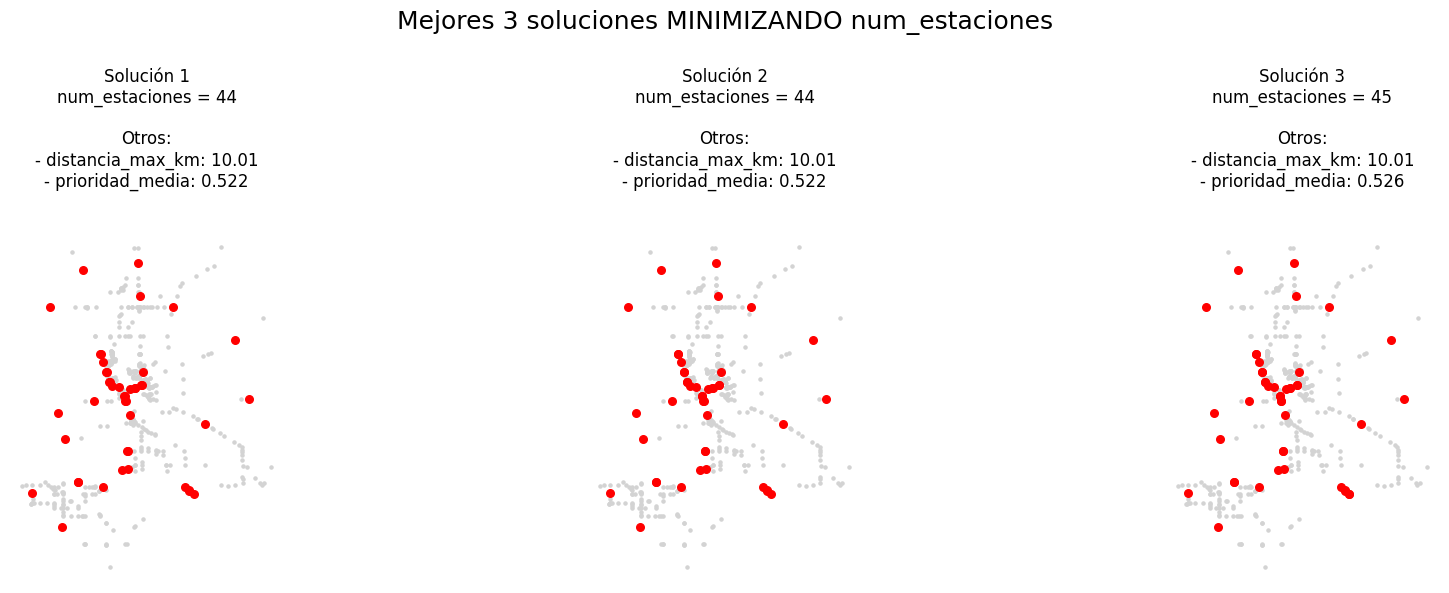

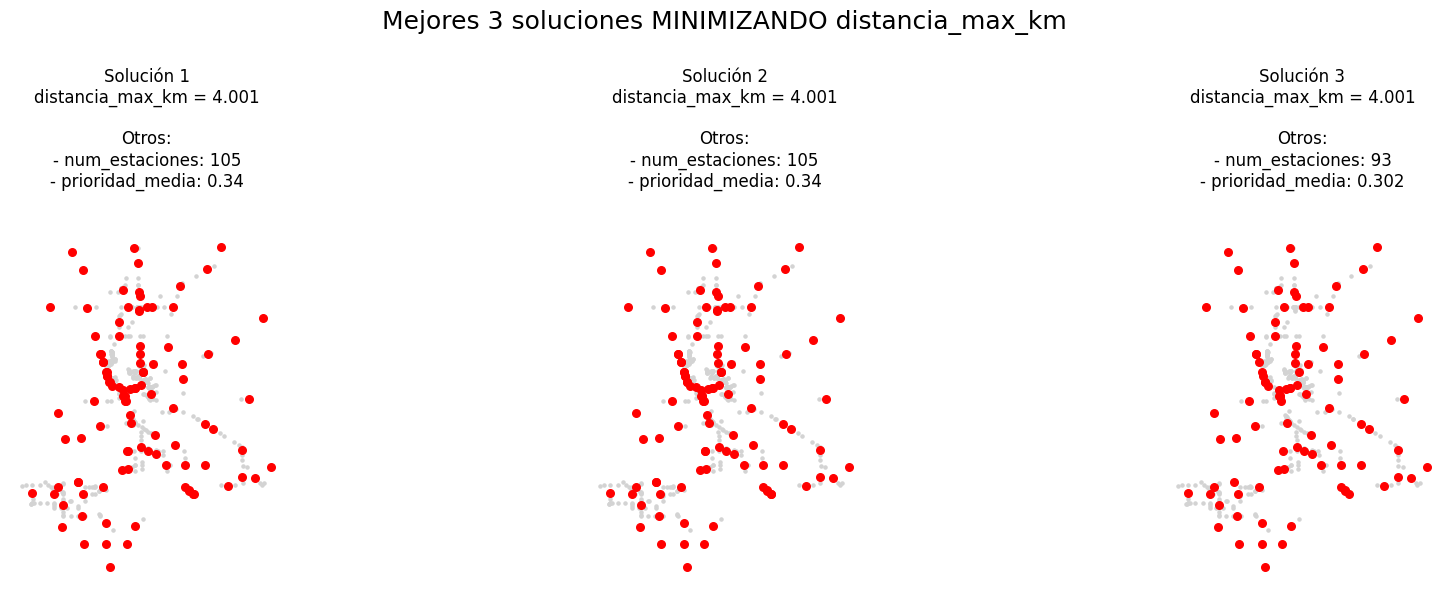

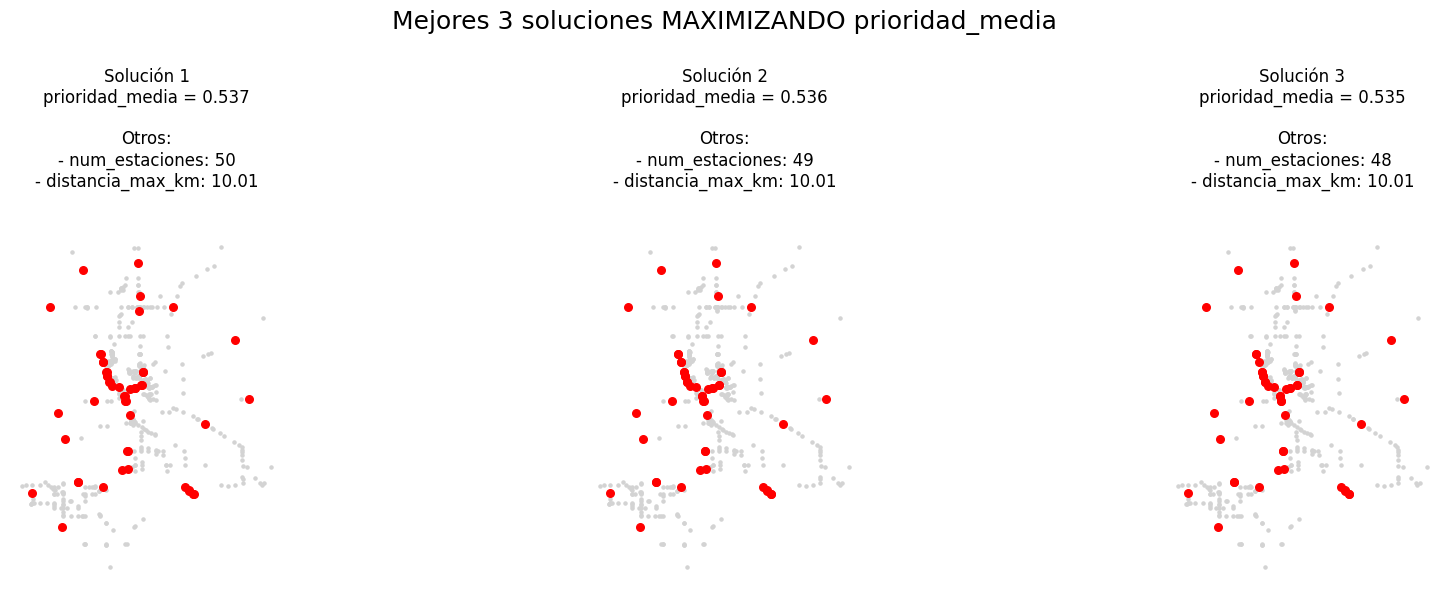

In [ ]:
def seleccionar_y_graficar(resultados, gdf, criterio="num_estaciones", n=3):
    
    """
    Selecciona y grafica las n mejores soluciones según un criterio.

    Criterios posibles:
        - "num_estaciones"      minimizar
        - "distancia_max_km"    minimizar
        - "prioridad_media"     maximizar
    """

    # Validación
    if criterio not in ["num_estaciones", "distancia_max_km", "prioridad_media"]:
        raise ValueError("Criterio inválido")

    # Ve si se maximiza o se minimiza
    if criterio == "prioridad_media":
        mejores = resultados.sort_values(by=criterio, ascending=False).head(n)  # MAXIMIZAR
        titulo_global = f"Mejores {n} soluciones MAXIMIZANDO {criterio}"
    else:
        mejores = resultados.sort_values(by=criterio, ascending=True).head(n)   # MINIMIZAR
        titulo_global = f"Mejores {n} soluciones MINIMIZANDO {criterio}"

    # Crea figura
    fig, ax = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1:
        ax = [ax]
    fig.suptitle(titulo_global, fontsize=18)

    for idx, (i, sol) in enumerate(mejores.iterrows()):
        ax_i = ax[idx]
        gdf.plot(ax=ax_i, color="lightgray", markersize=5)
        osmids = sol["estaciones_identificadores"]
        estaciones_gdf = gdf[gdf["osmid"].isin(osmids)]
        estaciones_gdf.plot(ax=ax_i, color="red", markersize=30)
        valor_opt = sol[criterio]
        otros = {
            "num_estaciones": sol["num_estaciones"],
            "distancia_max_km": round(sol["distancia_max_km"], 3),
            "prioridad_media": round(sol["prioridad_media"], 3),
        }
        del otros[criterio]
        texto = (
            f"Solución {idx+1}\n"
            f"{criterio} = {round(valor_opt, 3)}\n\n"
            f"Otros:\n"
        )
        for k, v in otros.items():
            texto += f"- {k}: {v}\n"
        ax_i.set_title(texto)
        ax_i.set_axis_off()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return mejores

sel1 = seleccionar_y_graficar(resultados, gdf, "num_estaciones", n=3)
sel2 = seleccionar_y_graficar(resultados, gdf, "distancia_max_km", n=3)
sel3 = seleccionar_y_graficar(resultados, gdf, "prioridad_media", n=3)


In [ ]:
def validar_soluciones(problem, X, F, gdf):
    resultados = []
    coords = np.vstack((gdf.geometry.x, gdf.geometry.y)).T
    n_nodos = len(gdf)
    n_sol = len(X)

    # FUNCION AUXILIAR DE DOMINANCIA
    def domina(fa, fb):
        """
        True si fa domina a fb.
        (fa <= fb en todos los objetivos y fa < fb en al menos uno)
        """
        return np.all(fa <= fb) and np.any(fa < fb)

    # CALCULO DE LAS METRICAS REALES
    for i in range(n_sol):
        individuo = np.round(X[i]).astype(int)
        estaciones_idx = np.where(individuo == 1)[0]
        estaciones_osmid = gdf.iloc[estaciones_idx]["osmid"].tolist()
        
        num_estaciones = int(np.sum(individuo))
        prioridad_media = 1 - F[i, 2]
        f2_max_real = (F[i,1] * problem.d_max)

        if len(estaciones_idx) > 0:
            dist_matrix = pairwise_distances(coords, coords[estaciones_idx], metric='euclidean')
            dist_min = dist_matrix.min(axis=1)
        else:
            dist_min = np.full(n_nodos, problem.d_max + problem.penalizacion)
        
        cobertura_promedio = dist_min.mean()
        porcentaje_cubiertos = np.sum(dist_min <= problem.d_max) / n_nodos * 100
        eficiencia = porcentaje_cubiertos / max(1, num_estaciones)

        resultados.append({
            "indice": i,
            "num_estaciones": num_estaciones,
            "distancia_max": f2_max_real,
            "cobertura_promedio": cobertura_promedio,
            "prioridad_media": prioridad_media,
            "%_nodos_cubiertos": porcentaje_cubiertos,
            "eficiencia": eficiencia,
            "estaciones_osmid": estaciones_osmid
        })

    df_validacion = pd.DataFrame(resultados)

    # CALCULO DE DOMINANCIA
    dominada = []
    for i in range(n_sol):
        f_i = F[i]
        es_dominada = False
        for j in range(n_sol):
            if i == j:
                continue
            if domina(F[j], f_i):
                es_dominada = True
                break
        dominada.append(es_dominada)

    df_validacion["dominada"] = dominada
    df_validacion["frente"] = df_validacion["dominada"].apply(lambda x: "Dominada" if x else "Pareto")

    return df_validacion

validacion = validar_soluciones(EVChargingProblem3F(gdf, d_max=d_max, factor_estaciones=factor_est), res.X, res.F, gdf)
print([validacion])

[     indice  num_estaciones  distancia_max  cobertura_promedio  \
0         0              49   10010.000000         4380.471428   
1         1              85    4218.420346         1547.112525   
2         2              50   10010.000000         4258.804894   
3         3              44   10010.000000         4393.532857   
4         4             105    4000.518146         1414.494674   
5         5             105    4000.518146         1414.494674   
6         6              59    8467.935114         3073.091539   
7         7              59    8467.935114         3073.091539   
8         8              44   10010.000000         4393.532857   
9         9              75    6687.786503         2242.597457   
10       10              78    6375.589899         2044.438517   
11       11              90    4741.605704         1590.632358   
12       12              81    5597.821686         1969.924005   
13       13              87    4548.171710         1616.791460   
14       